# Data loading

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras

In [4]:
DF = pd.read_csv('Full_DF_for_LSTM.csv',parse_dates=['market_data'], index_col='market_data')

In [6]:
DF.head(8)

,Average_sentimen,Tweet_count,Close,Volume,LogReturns,Sign
market_data,,,,,,
2011-12-05 21:00:00+00:00,0.510000,3,2.294667,17401500.0,0.054326,1
2011-12-21 21:00:00+00:00,0.093333,6,1.838000,25582500.0,-0.221910,0
2011-12-22 21:00:00+00:00,0.668750,4,1.851333,15141000.0,0.007228,1
2011-12-27 21:00:00+00:00,0.175000,8,1.904667,11662500.0,0.028401,1
2011-12-28 21:00:00+00:00,0.880000,1,1.900667,8628000.0,-0.002102,0
2011-12-29 21:00:00+00:00,0.896250,4,1.915333,7323000.0,0.007687,1
2011-12-30 21:00:00+00:00,-0.154444,9,1.904000,5097000.0,-0.005935,0
2012-01-03 21:00:00+00:00,-0.150909,11,1.872000,13921500.0,-0.016950,0


# Data split train|validation|test

In [8]:
DF = DF[['Average_sentimen','Tweet_count','Volume','LogReturns','Sign']] 

In [10]:
n_total = len(DF)
n_test = int(n_total*0.80)
n_val = int(n_total*0.60)

In [12]:
DF_train = DF.iloc[:n_val]
DF_val = DF.iloc[n_val:n_test]
DF_test = DF.iloc[n_test:]

In [14]:
DF = pd.read_csv('Full_DF_for_LSTM.csv',parse_dates=['market_data'], index_col='market_data')

In [16]:
DF_train.index[-1]

Timestamp('2020-01-23 21:00:00+0000', tz='UTC')

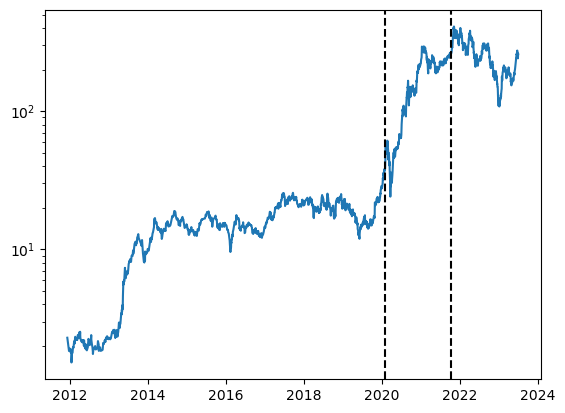

In [20]:
import matplotlib.pyplot as plt
plt.plot(DF['Close'])
plt.yscale('log')
plt.axvline(DF_val.index[0],color='k',linestyle='--')
plt.axvline(DF_test.index[0],color='k',linestyle='--')

# Percentiles
We want to divide sample in classes:\
0 if log return is under a certain level L1,\
2 if log return is over a certain level L2,\
1 if log return is betweet L1 and L2.\
We take L1 = 20 percentile of the distribution of log returns,
and L2 = 80 percentile of the distribution of log returns

In [22]:
DF_train['LogReturns'].describe()

count    1245.000000
mean        0.002301
std         0.040252
min        -0.221910
25%        -0.016880
50%         0.001945
75%         0.020549
max         0.235174
Name: LogReturns, dtype: float64

In [24]:
L1 = np.percentile(DF_train['LogReturns'],20)
L2 = np.percentile(DF_train['LogReturns'],80)

In [26]:
print(L1,L2)

-0.02242293542578862 0.02687675348763422


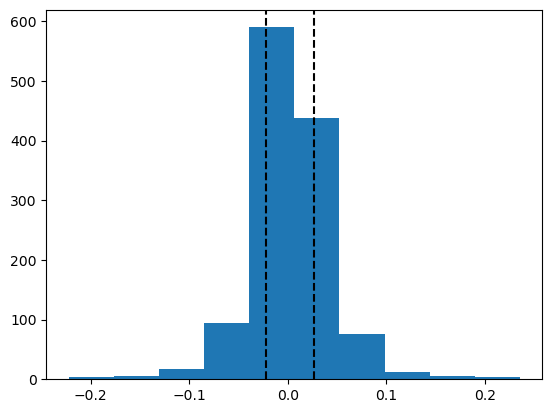

In [24]:
import matplotlib.pyplot as plt
plt.hist(DF_train['LogReturns'])
plt.axvline(x=L1, color='k',linestyle='--', label = 'L1' )
plt.axvline(x=L2, color='k',linestyle='--', label = 'L2' )

# 3 Classes split
Sign will be the classes label

In [28]:
# Train 
DF_train = DF_train.copy()
DF_train['Sign'] = 1
DF_train['Sign'] = np.where(DF_train['LogReturns']>L2, 2, DF_train['Sign'])
DF_train['Sign'] = np.where(DF_train['LogReturns']<L1,0,DF_train['Sign'])

In [30]:
DF_train['Sign'].value_counts()

Sign
1    747
2    249
0    249
Name: count, dtype: int64

In [32]:
# Validation
DF_val = DF_val.copy()
DF_val['Sign'] = 1
DF_val['Sign'] = np.where(DF_val['LogReturns']>L2, 2, DF_val['Sign'])
DF_val['Sign'] = np.where(DF_val['LogReturns']<L1,0,DF_val['Sign'])

In [34]:
DF_val['Sign'].value_counts()

Sign
1    224
2    102
0     89
Name: count, dtype: int64

In [36]:
# Test
DF_test = DF_test.copy()
DF_test['Sign'] = 1
DF_test['Sign'] = np.where(DF_test['LogReturns']>L2, 2, DF_test['Sign'])
DF_test['Sign'] = np.where(DF_test['LogReturns']<L1,0,DF_test['Sign'])

In [38]:
DF_test['Sign'].value_counts()

Sign
1    212
0    106
2     98
Name: count, dtype: int64

# Data preprocessing

In [40]:
# np array
d_train_sent = DF_train.values
d_val_sent = DF_val.values
d_test_sent = DF_test.values

In [42]:
# sequence function
window_width = 128
def create_sequence(data,seq_length = window_width, j=2, k=3):
    X = []
    y = []
    log_returns = []
    for i in range(seq_length,len(data)):
        X.append(data[i-seq_length:i,:])
        y.append(data[i,j])
        log_returns.append(data[i,k])
    return np.array(X), np.array(y), np.array(log_returns)

In [44]:
# sequences
X_train_sent, y_train_sent, y_train_return = create_sequence(d_train_sent,j=4)
X_val_sent , y_val_sent, y_val_return = create_sequence(d_val_sent,j=4)
X_test_sent, y_test_sent, y_test_return = create_sequence(d_test_sent,j=4)

In [46]:
# reshaping for LSTM
y_train_sent = y_train_sent.reshape(-1,1)
y_test_sent = y_test_sent.reshape(-1,1)
y_val_sent = y_val_sent.reshape(-1,1)


In [48]:
# shape chek
print(X_train_sent.shape,y_train_sent.shape)
print(X_val_sent.shape,y_val_sent.shape)
print(X_test_sent.shape,y_test_sent.shape)


(1117, 128, 5) (1117, 1)
(287, 128, 5) (287, 1)
(288, 128, 5) (288, 1)


In [50]:
# scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
# Train
X_train_sent_reshaped = X_train_sent.reshape(-1,5)
X_train_sent_scaled_MM = scaler.fit_transform(X_train_sent_reshaped)
X_train_sent_scaled_MM = X_train_sent_scaled_MM.reshape(X_train_sent.shape)
# Validation
X_val_sent_scaled_MM = scaler.transform(X_val_sent.reshape(-1,5)).reshape(X_val_sent.shape)
# Test
X_test_sent_scaled_MM = scaler.transform(X_test_sent.reshape(-1,5)).reshape(X_test_sent.shape)


# Model
-Architecture:\
Bidirectional LSTM 64 Units, dropout (0.2), weight initializer he normal\
Bidirectional LSTM 32 Units, dropout (0.2), weight initializer he normal\
Dense layer 16 units, activation relu\
Output: Dense layer 3 units, activation softmax. \
-Optimizer:\
Adam, starting learning rate = 0.003 and decreasing on plateau with factor 0.5.\
-Training:\
100 epochs, batch size 32.\
-Loss:\
sparse categorical crossentropy

In [52]:
Model_sentiment_3_3 = keras.models.Sequential([
    keras.layers.Input(shape=(128,5)),
    keras.layers.Bidirectional(keras.layers.LSTM(64, return_sequences=True, dropout=0.2, kernel_initializer='he_normal')),
    keras.layers.Bidirectional(keras.layers.LSTM(32, return_sequences=False, dropout=0.2, kernel_initializer='he_normal')),
    keras.layers.Dense(16,activation='relu'),
    keras.layers.Dense(3,activation='softmax')
])

In [211]:
Model_sentiment_3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional)      │ (None, 128, 128)            │          35,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 78,147 (305.26 KB)

 Trainable params: 78,147 (305.26 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
# Callback Best model
CB_Best_sent = keras.callbacks.ModelCheckpoint('LSTM_Best_3_3_second.keras',
                                         monitor='loss',
                                         save_best_only=True,
                                         )
CB_lr_sent = tf.keras.callbacks.ReduceLROnPlateau(monitor='loss', 
                                         patience=5,         
                                         factor=0.5,            
                                         min_lr=1e-7,           
                                         verbose=1               
                                         )

In [62]:
Model_sentiment_3_3.compile(loss = 'sparse_categorical_crossentropy',
                        optimizer=keras.optimizers.Adam(learning_rate=0.003),
                        metrics=['accuracy'])

In [58]:
# balancing classes 
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1, 2])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_sent.flatten()
)

class_weight = dict(zip(classes, weights))

In [64]:
Model_sentiment_3_3.fit(X_train_sent_scaled_MM, y_train_sent, epochs=50,
                     validation_data=(X_val_sent_scaled_MM,y_val_sent),
                     callbacks=[CB_Best_sent,CB_lr_sent],
                     class_weight=class_weight)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 162ms/step - accuracy: 0.3154 - loss: 1.0966 - val_accuracy: 0.2056 - val_loss: 1.1108 - learning_rate: 0.0030
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.2426 - loss: 1.1059 - val_accuracy: 0.2265 - val_loss: 1.1054 - learning_rate: 0.0030
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.2452 - loss: 1.1124 - val_accuracy: 0.3380 - val_loss: 1.0941 - learning_rate: 0.0030
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.4584 - loss: 1.0929 - val_accuracy: 0.2369 - val_loss: 1.1066 - learning_rate: 0.0030
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.3433 - loss: 1.1015 - val_accuracy: 0.5749 - val_loss: 1.0836 - learning_rate: 0.0030
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.3974 - loss: 1.1059 - val_accuracy: 0.5714 - val_loss: 1.0672 - learning_rate: 0.0030
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.5452 - loss: 1.0892 - val_a

In [52]:
Model_sent_best_3_3 = keras.models.load_model('LSTM_Best_3_3_second.keras')

In [68]:
y_probs_train = Model_sent_best_3_3.predict(X_train_sent_scaled_MM)

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step


In [70]:
y_probs_train

array([[0.32330263, 0.2809609 , 0.39573655],
       [0.33249184, 0.32426605, 0.3432421 ],
       [0.32729688, 0.2703362 , 0.40236682],
       ...,
       [0.33479372, 0.2451942 , 0.42001203],
       [0.33554298, 0.27070755, 0.39374948],
       [0.33643913, 0.25193858, 0.41162235]], dtype=float32)

In [72]:
predictions = y_probs_train.argmax(axis=1)

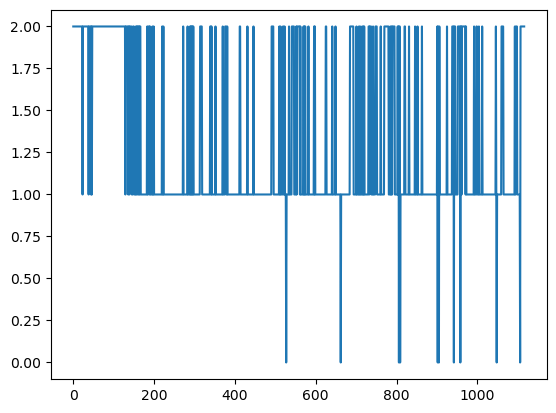

In [74]:
plt.plot(predictions)

# Back test train


# Long short strategy

Total Return: 11.6383
Sharpe Ratio: 1.3662
Max Drawdown: -0.4509
Win rate: 0.1647
Not lose rate :0.8612
Trades: 329


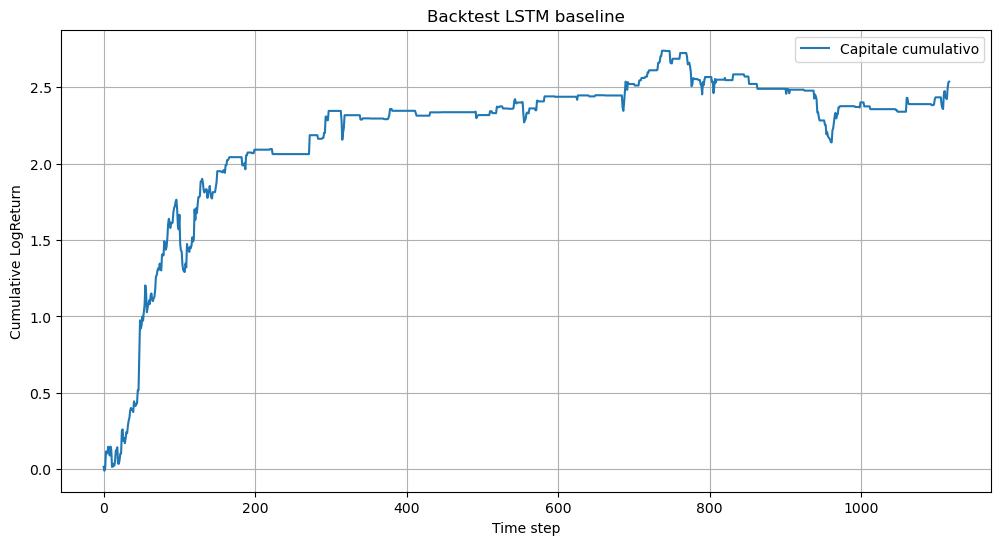

In [76]:
# long short and flat signals
signals_sent = (predictions-1).astype(int)  #0 (flat),  +1 (long), -1(short)

# Actual LogReturns test set
log_returns_train_sent = d_train_sent[128:, 3] 

# PnL
pnl_sent = signals_sent * log_returns_train_sent

# Cumulative log PnL
cum_log_pnl_sent = np.cumsum(pnl_sent)

#Equity
equity_sent = np.exp(cum_log_pnl_sent)

# Metrics
total_return_sent = np.exp(cum_log_pnl_sent[-1]) - 1
sharpe_ratio_sent = np.mean(pnl_sent) / (np.std(pnl_sent,ddof=1) + 1e-7) * np.sqrt(252) 
drawdown_sent = equity_sent / np.maximum.accumulate(equity_sent) - 1
max_drawdown_sent = drawdown_sent.min()
w_rate_sent = (pnl_sent > 0).mean()
non_lose_rate = (pnl_sent>=0).mean()


print(f"Total Return: {total_return_sent:.4f}")
print(f"Sharpe Ratio: {sharpe_ratio_sent:.4f}")
print(f"Max Drawdown: {max_drawdown_sent:.4f}")
print(f"Win rate: {w_rate_sent:.4f}")
print(f"Not lose rate :{non_lose_rate:.4f}")
print(f"Trades: {(signals_sent>0).sum()}")

plt.figure(figsize=(12,6))
plt.plot(cum_log_pnl_sent, label='log growth factor')
plt.title('Backtest')
plt.xlabel('Time step')
plt.ylabel('Cumulative LogReturn')
plt.grid(True)
plt.legend()

# Long only strategy

Total Return: 12.9408
Sharpe Ratio: 1.4324
Max Drawdown: -0.4370
Win rate: 0.1620
Not lose rate :0.8675
Trades: 329


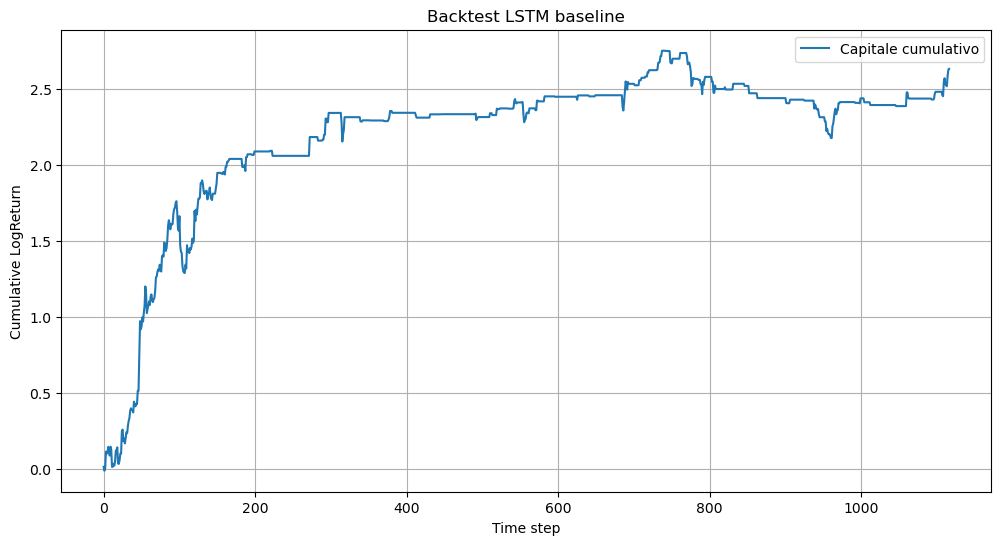

In [78]:
# long signals
signals_sent = (predictions==2).astype(int)  #0 (flat),  +1 (long)

# Actual LogReturns test set
log_returns_train_sent = d_train_sent[128:, 3] 

# PnL
pnl_sent = signals_sent * log_returns_train_sent

# Cumulative log PnL
cum_log_pnl_sent = np.cumsum(pnl_sent)

#Equity
equity_sent = np.exp(cum_log_pnl_sent)

# Metrics
total_return_sent = np.exp(cum_log_pnl_sent[-1]) - 1
sharpe_ratio_sent = np.mean(pnl_sent) / (np.std(pnl_sent,ddof=1) + 1e-7) * np.sqrt(252) 
drawdown_sent = equity_sent / np.maximum.accumulate(equity_sent) - 1
max_drawdown_sent = drawdown_sent.min()
w_rate_sent = (pnl_sent > 0).mean()
non_lose_rate = (pnl_sent>=0).mean()


print(f"Total Return: {total_return_sent:.4f}")
print(f"Sharpe Ratio: {sharpe_ratio_sent:.4f}")
print(f"Max Drawdown: {max_drawdown_sent:.4f}")
print(f"Win rate: {w_rate_sent:.4f}")
print(f"Not lose rate :{non_lose_rate:.4f}")
print(f"Trades: {(signals_sent>0).sum()}")

plt.figure(figsize=(12,6))
plt.plot(cum_log_pnl_sent, label='log growth factor')
plt.title('Backtest')
plt.xlabel('Time step')
plt.ylabel('Cumulative LogReturn')
plt.grid(True)
plt.legend()

# Back test test set

In [56]:
y_probs_test = Model_sent_best_3_3.predict(X_test_sent_scaled_MM)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


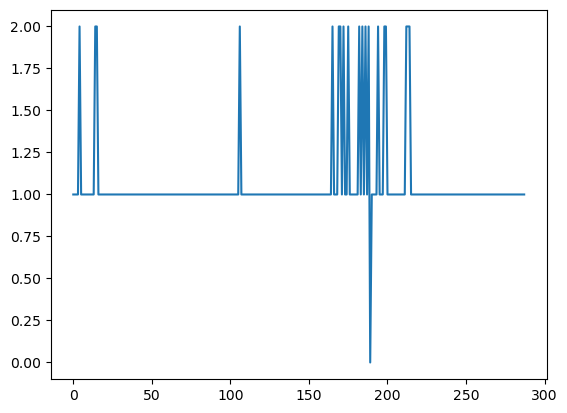

In [58]:
predictions = y_probs_test.argmax(axis=1)
plt.plot(predictions)

# Long Short strategy

Total Return: 0.3838
Sharpe Ratio: 1.5610
Max Drawdown: -0.0674
Win rate: 0.6500
Trades: 19


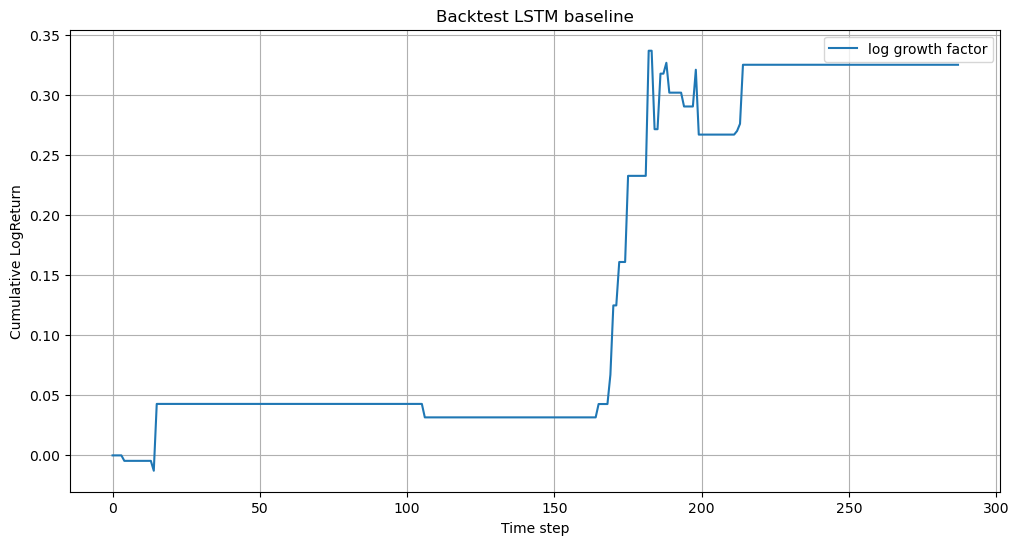

In [64]:
# long short and flat signals
signals_sent = (predictions-1).astype(int)  #0 (flat),  +1 (long), -1(short)

# Actual LogReturns test set
log_returns_test_sent = d_test_sent[128:, 3] 

# PnL
pnl_sent = signals_sent * log_returns_test_sent

# Cumulative log PnL
cum_log_pnl_sent = np.cumsum(pnl_sent)

#Equity
equity_sent = np.exp(cum_log_pnl_sent)

# Metrics
total_return_sent = np.exp(cum_log_pnl_sent[-1]) - 1
sharpe_ratio_sent = np.mean(pnl_sent) / (np.std(pnl_sent,ddof=1) + 1e-7) * np.sqrt(252) 
drawdown_sent = equity_sent / np.maximum.accumulate(equity_sent) - 1
max_drawdown_sent = drawdown_sent.min()
w_rate_sent = (pnl_sent > 0).sum()/(pnl_sent!=0).sum()



print(f"Total Return: {total_return_sent:.4f}")
print(f"Sharpe Ratio: {sharpe_ratio_sent:.4f}")
print(f"Max Drawdown: {max_drawdown_sent:.4f}")
print(f"Win rate: {w_rate_sent:.4f}")
print(f"Trades: {(signals_sent>0).sum()}")

plt.figure(figsize=(12,6))
plt.plot(cum_log_pnl_sent, label='log growth factor')
plt.title('Backtest')
plt.xlabel('Time step')
plt.ylabel('Cumulative LogReturn')
plt.grid(True)
plt.legend()

# Long only strategy

Total Return: 0.4186
Sharpe Ratio: 1.6956
Max Drawdown: -0.0632
Win rate: 0.6842
Trades: 19


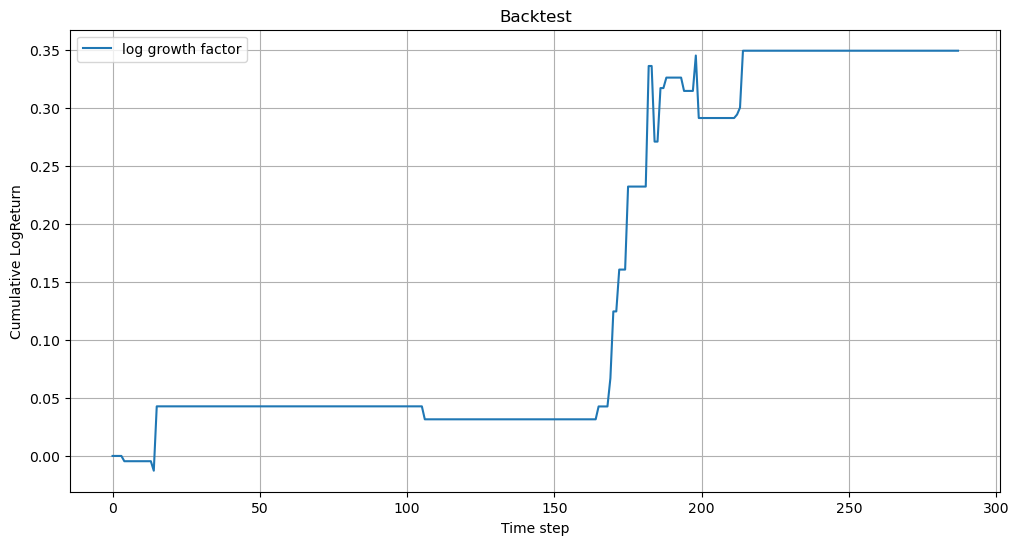

In [68]:
# long  signals
signals_sent = (predictions==2).astype(int)  #0 (flat),  +1 (long)

# Actual LogReturns test set
log_returns_test_sent = d_test_sent[128:, 3] 

# PnL
pnl_sent = signals_sent * log_returns_test_sent

# Cumulative log PnL
cum_log_pnl_sent = np.cumsum(pnl_sent)

#Equity
equity_sent = np.exp(cum_log_pnl_sent)

# Metrics
total_return_sent = np.exp(cum_log_pnl_sent[-1]) - 1
sharpe_ratio_sent = np.mean(pnl_sent) / (np.std(pnl_sent,ddof=1) + 1e-7) * np.sqrt(252) 
drawdown_sent = equity_sent / np.maximum.accumulate(equity_sent) - 1
max_drawdown_sent = drawdown_sent.min()
w_rate_sent = (pnl_sent > 0).sum()/(pnl_sent!=0).sum()
non_lose_rate = (pnl_sent>=0).mean()


print(f"Total Return: {total_return_sent:.4f}")
print(f"Sharpe Ratio: {sharpe_ratio_sent:.4f}")
print(f"Max Drawdown: {max_drawdown_sent:.4f}")
print(f"Win rate: {w_rate_sent:.4f}")
print(f"Trades: {(signals_sent>0).sum()}")


plt.figure(figsize=(12,6))
plt.plot(cum_log_pnl_sent, label='log growth factor')
plt.title('Backtest')
plt.xlabel('Time step')
plt.ylabel('Cumulative LogReturn')
plt.grid(True)
plt.legend()